In [1]:
from astropy.io import ascii
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import galstreams


In [2]:
tbl_data = ascii.read(
    "../data/apjad382dt1_mrt.txt",
    format="cds"   
)

tbl_ids = pd.read_csv("../data/gaia_stream_id.csv", 
                      sep='\t')

print(tbl_data.colnames)
print(tbl_ids.columns)

tbl_ids[(tbl_ids['Name'] == 'Fjorm') | (tbl_ids['Name'] == 'Gjoll') | (tbl_ids['Name'] == 'Pal-5')]

['Gaia', 'RAdeg', 'DEdeg', 'plx', 'pmRA', 'pmDE', 'Gmag', '(B-R)', 'VHel', 'e_VHel', 'r_VHel', 'Stream']
Index(['s_ID', 'Name', 'Sample', 'alpha_0', 'alpha_pole', 'delta_pole', 'n',
       'n _v', 'M_sstarf', 'angl0[Fe/H]angr0', 'References', 'Remarks',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23'],
      dtype='object')


,s_ID,Name,Sample,alpha_0,alpha_pole,delta_pole,n,n _v,M_sstarf,angl0[Fe/H]angr0,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
33,34,Gjoll,1,154.403,158.539,43.545,607,40,2100,-1.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,47,Fjorm,1,189.867,103.086,19.455,297,29,1700,-2.23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,61,Pal-5,1,229.022,320.298,-54.042,129,69,"17,000",-1.41,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Pal5: 129 stars
NGC3201: 607 stars
M68: 297 stars


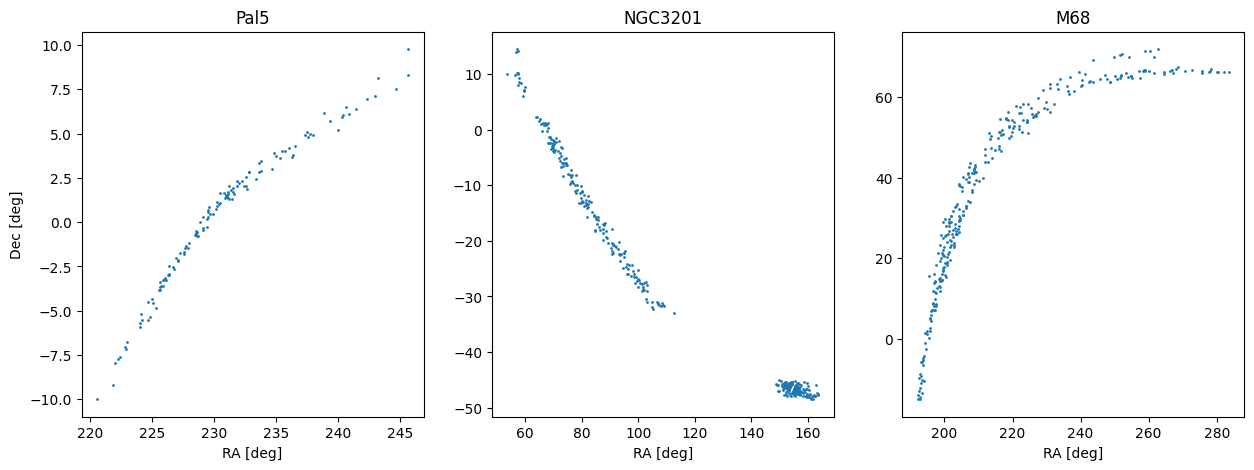

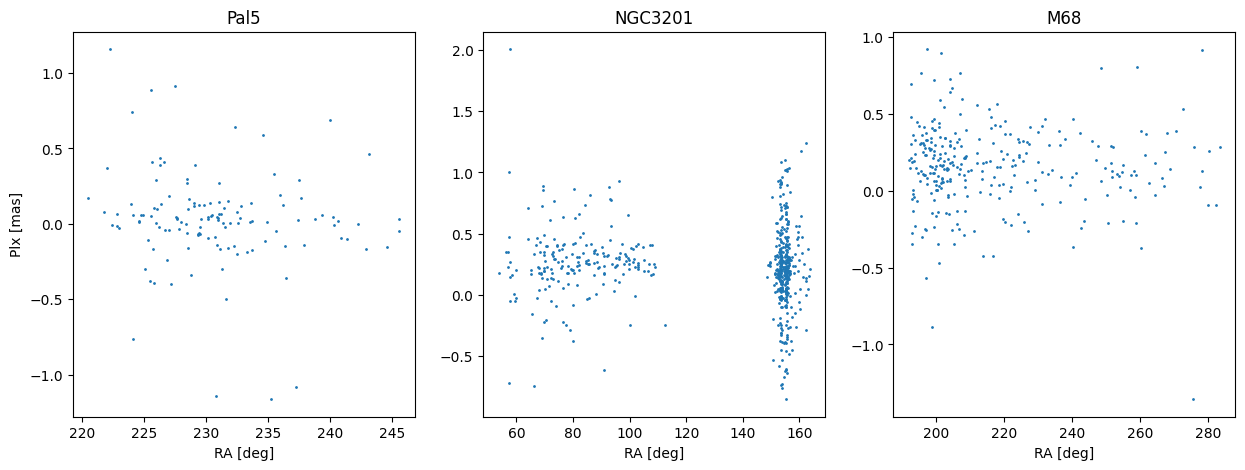

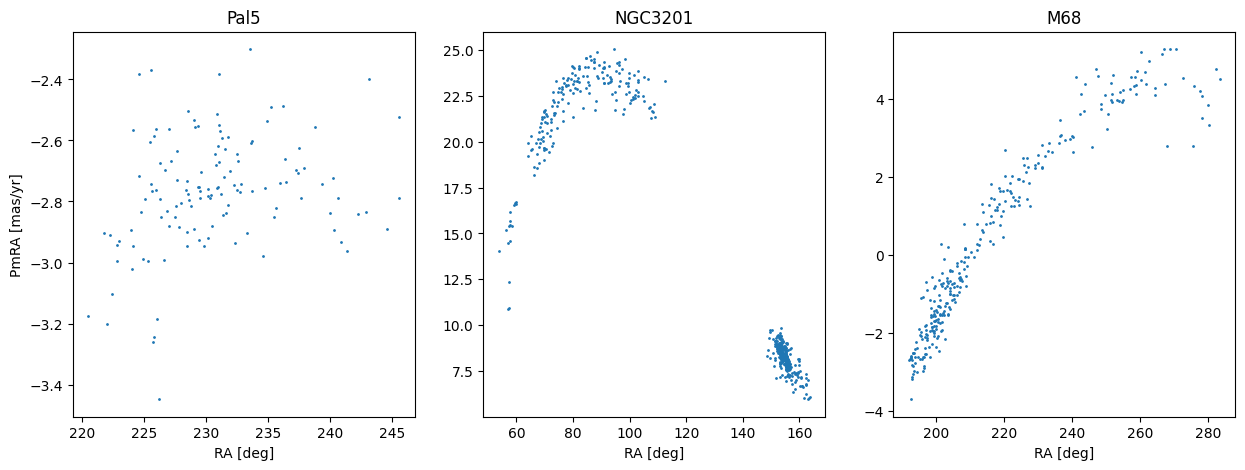

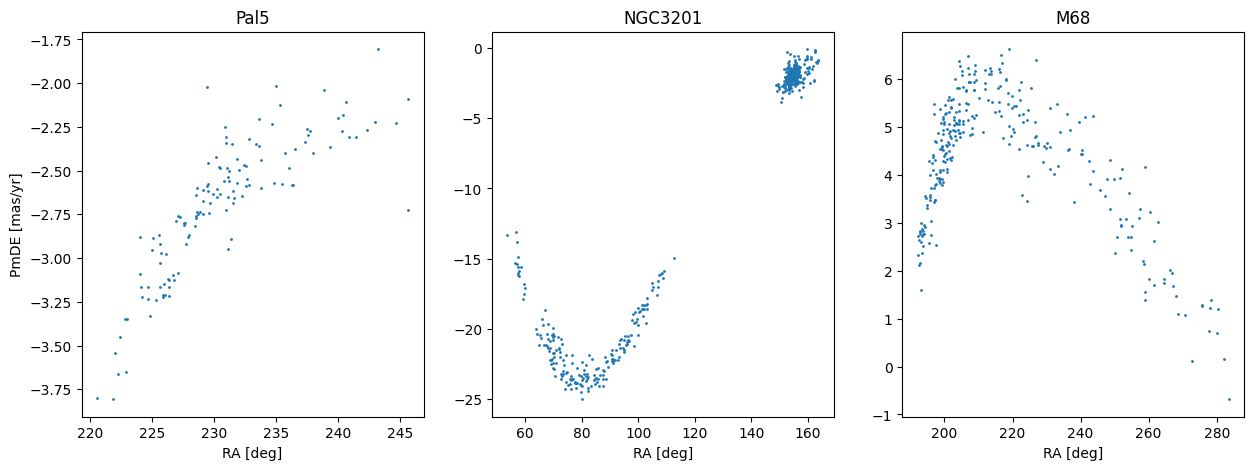

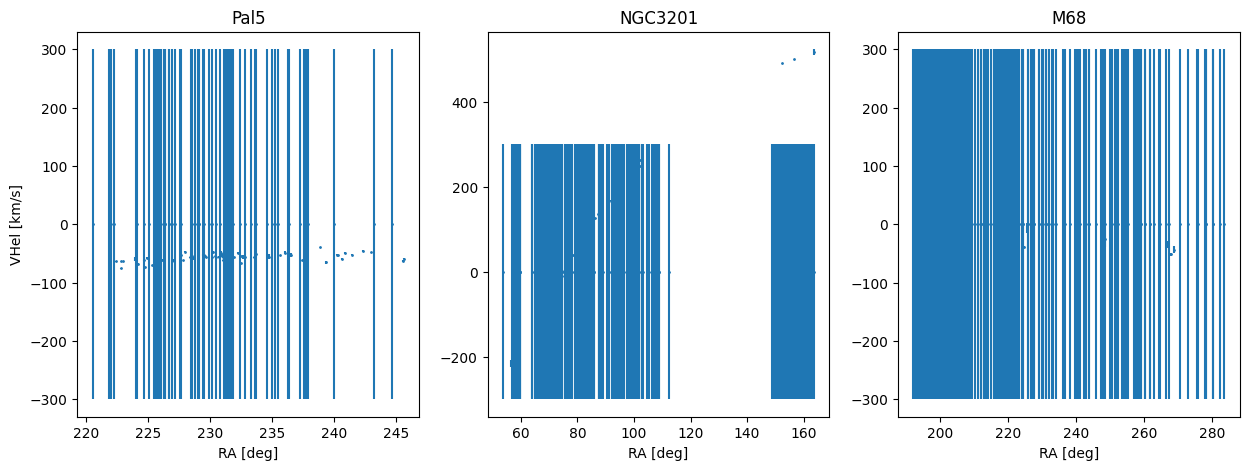

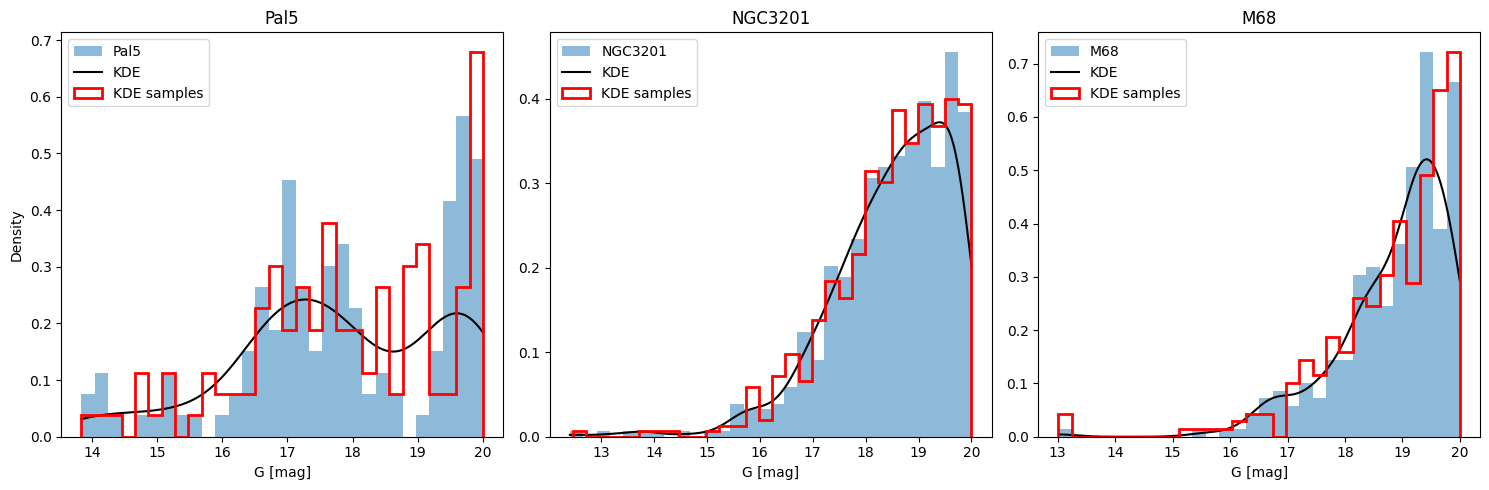

In [3]:
name_to_plot = ['Pal5', 'NGC3201', 'M68']
name_for_id = ['Pal-5', 'Gjoll', 'Fjorm']
particles = {}

for name_id, name_plot in zip(name_for_id, name_to_plot):
    source_id = tbl_ids.loc[tbl_ids['Name'] == name_id, 's_ID'].values[0]
    tbl_subset = tbl_data[tbl_data['Stream'] == source_id]
    print(f"{name_plot}: {len(tbl_subset)} stars")
    particles[name_plot] = {'Ra': np.array([a for a in tbl_subset['RAdeg']]),\
                            'Dec': np.array([a for a in tbl_subset['DEdeg']]),\
                            'Plx': np.array([a for a in tbl_subset['plx']]),\
                            'PmRA': np.array([a for a in tbl_subset['pmRA']]),\
                            'PmDE': np.array([a for a in tbl_subset['pmDE']]),\
                            'VHel': np.array([a for a in tbl_subset['VHel']]),\
                            'e_VHel': np.array([a for a in tbl_subset['e_VHel']]),\
                            'Gmag': np.array([a for a in tbl_subset['Gmag']]),\
                            }

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['Dec'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('Dec [deg]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['Plx'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('Plx [mas]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['PmRA'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('PmRA [mas/yr]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['PmDE'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('PmDE [mas/yr]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.errorbar(particles[name]['Ra'], particles[name]['VHel'], yerr=particles[name]['e_VHel'], fmt='o', markersize=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('VHel [km/s]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    data = particles[name]['Gmag']
    ax.hist(data, bins=30, label=name, alpha=0.5, density=True)
    # KDE
    kde = gaussian_kde(data)
    x_grid = np.linspace(np.min(data), np.max(data), 1_000)
    ax.plot(x_grid, kde(x_grid), color='k', label='KDE')
    samples = kde.resample((len(data*10), )).reshape(len(data))
    samples = np.clip(samples, np.min(data), np.max(data))
    ax.hist(samples, bins=30, density=True, histtype='step', color='r', lw=2, label='KDE samples')
    ax.set_xlabel('G [mag]')
    if i == 0:
        ax.set_ylabel('Density')
    ax.set_title(name)
    ax.legend()
plt.tight_layout()

In [4]:
mws = galstreams.MWStreams(verbose=False, implement_Off=True, print_topcat_friendly_files=False);


Initializing galstreams library from master_log... 


        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use n

Track name for Pal 5: ['Pal5-I24', 'Pal5-I21', 'Pal5-PW19', 'Pal5-S20']
Track name for NGC 3201: ['Gjoll-I21', 'Gjoll-I24', 'NGC3201-I21', 'NGC3201-P21']
Track name for M68: ['Fjorm-I21', 'Fjorm-I24', 'M68-I21', 'M68-P19']


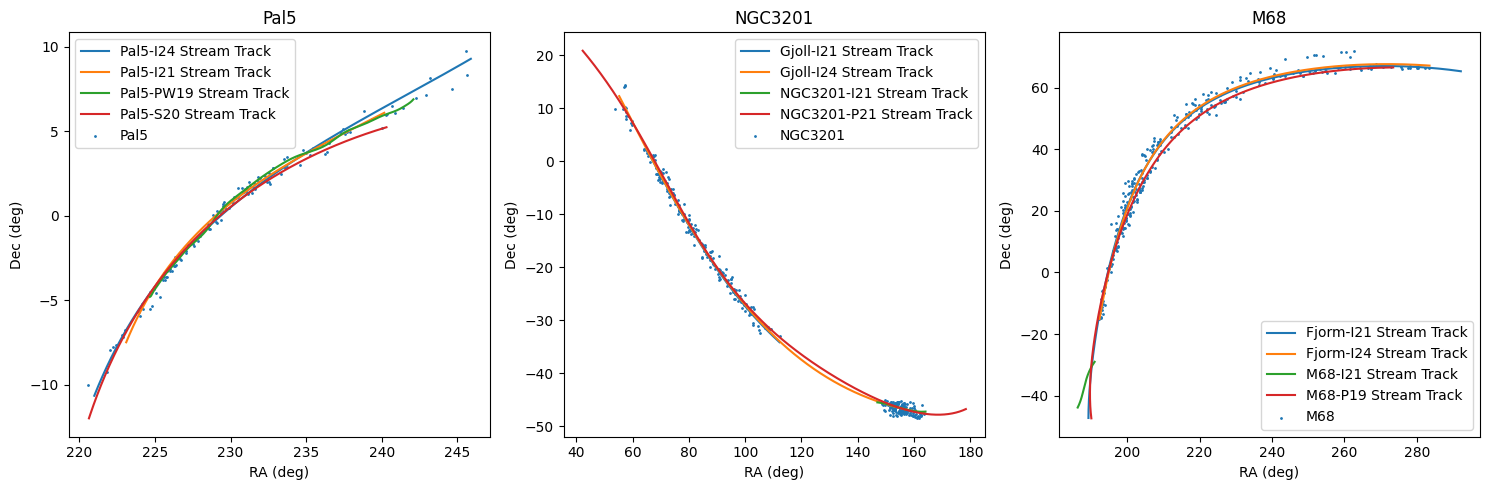

In [5]:
track_name_Pal5 = mws.get_track_names_for_stream('Pal5', On_only=True)
track_name_NGC3201 = mws.get_track_names_for_stream('NGC3201', On_only=True)
track_name_M68 = mws.get_track_names_for_stream('M68', On_only=True)

print("Track name for Pal 5:", track_name_Pal5)
print("Track name for NGC 3201:", track_name_NGC3201)
print("Track name for M68:", track_name_M68)


fig = plt.figure(figsize=(15,5), tight_layout=True)
ax = fig.add_subplot(131)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax2 = fig.add_subplot(132)
ax2.set_xlabel('RA (deg)')
ax2.set_ylabel('Dec (deg)')
ax3 = fig.add_subplot(133)
ax3.set_xlabel('RA (deg)')
ax3.set_ylabel('Dec (deg)')

for name in track_name_Pal5:
    track = mws[name].track
    ax.plot(track.ra, track.dec, label=f'{name} Stream Track', )

for name in track_name_NGC3201:
    track = mws[name].track
    ax2.plot(track.ra, track.dec, label=f'{name} Stream Track', )
# track_ngc3201 = mws[track_name_NGC3201[3]].track
# ax2.plot(track_ngc3201.ra, track_ngc3201.dec, label='NGC 3201 Stream Track', color='orange')

for name in track_name_M68:
    track = mws[name].track
    ax3.plot(track.ra, track.dec, label=f'{name} Stream Track', )
# track_m68 = mws[track_name_M68[0]].track
# ax3.plot(track_m68.ra, track_m68.dec, label='M68 Stream Track', color='green')


for i, name in enumerate(name_to_plot):
    if i==0:
        ax.scatter(particles[name]['Ra'], particles[name]['Dec'], s=1, label=name)
        ax.set_title(name)
    elif i==1:
        ax2.scatter(particles[name]['Ra'], particles[name]['Dec'], s=1, label=name)
        ax2.set_title(name)
    else:
        ax3.scatter(particles[name]['Ra'], particles[name]['Dec'], s=1, label=name)
        ax3.set_title(name)
    

ax.legend()
ax2.legend()
ax3.legend()



Track name for Pal 5: ['Pal5-I24', 'Pal5-I21', 'Pal5-PW19', 'Pal5-S20']
Track name for NGC 3201: ['Gjoll-I21', 'Gjoll-I24', 'NGC3201-I21', 'NGC3201-P21']
Track name for M68: ['Fjorm-I21', 'Fjorm-I24', 'M68-I21', 'M68-P19']


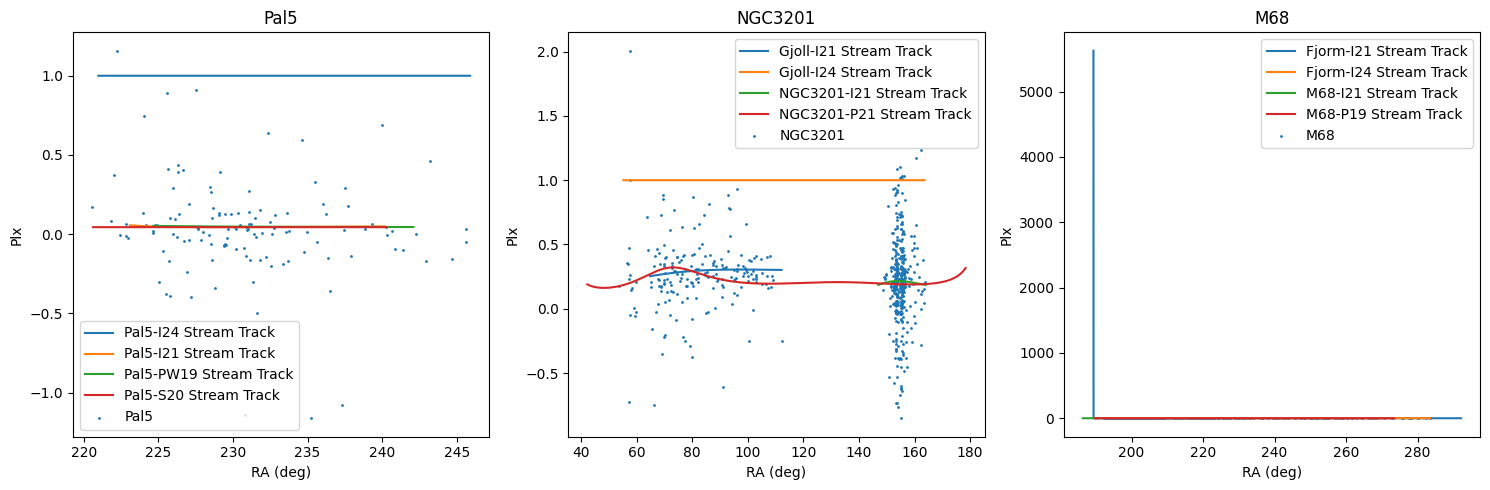

In [6]:
track_name_Pal5 = mws.get_track_names_for_stream('Pal5', On_only=True)
track_name_NGC3201 = mws.get_track_names_for_stream('NGC3201', On_only=True)
track_name_M68 = mws.get_track_names_for_stream('M68', On_only=True)

print("Track name for Pal 5:", track_name_Pal5)
print("Track name for NGC 3201:", track_name_NGC3201)
print("Track name for M68:", track_name_M68)


fig = plt.figure(figsize=(15,5), tight_layout=True)
ax = fig.add_subplot(131)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Plx')
ax2 = fig.add_subplot(132)
ax2.set_xlabel('RA (deg)')
ax2.set_ylabel('Plx')
ax3 = fig.add_subplot(133)
ax3.set_xlabel('RA (deg)')
ax3.set_ylabel('Plx')

for name in track_name_Pal5:
    track = mws[name].track
    ax.plot(track.ra, 1/track.distance, label=f'{name} Stream Track', )

for name in track_name_NGC3201:
    track = mws[name].track
    ax2.plot(track.ra, 1/track.distance, label=f'{name} Stream Track', )
# track_ngc3201 = mws[track_name_NGC3201[3]].track
# ax2.plot(track_ngc3201.ra, track_ngc3201.dec, label='NGC 3201 Stream Track', color='orange')

for name in track_name_M68:
    track = mws[name].track
    ax3.plot(track.ra, 1/track.distance, label=f'{name} Stream Track', )
# track_m68 = mws[track_name_M68[0]].track
# ax3.plot(track_m68.ra, track_m68.dec, label='M68 Stream Track', color='green')


for i, name in enumerate(name_to_plot):
    if i==0:
        ax.scatter(particles[name]['Ra'], particles[name]['Plx'], s=1, label=name)
        ax.set_title(name)
    elif i==1:
        ax2.scatter(particles[name]['Ra'], particles[name]['Plx'], s=1, label=name)
        ax2.set_title(name)
    else:
        ax3.scatter(particles[name]['Ra'], particles[name]['Plx'], s=1, label=name)
        ax3.set_title(name)
    

ax.legend()
ax2.legend()
ax3.legend()



Track name for Pal 5: ['Pal5-I24', 'Pal5-I21', 'Pal5-PW19', 'Pal5-S20']
Track name for NGC 3201: ['Gjoll-I21', 'Gjoll-I24', 'NGC3201-I21', 'NGC3201-P21']
Track name for M68: ['Fjorm-I21', 'Fjorm-I24', 'M68-I21', 'M68-P19']


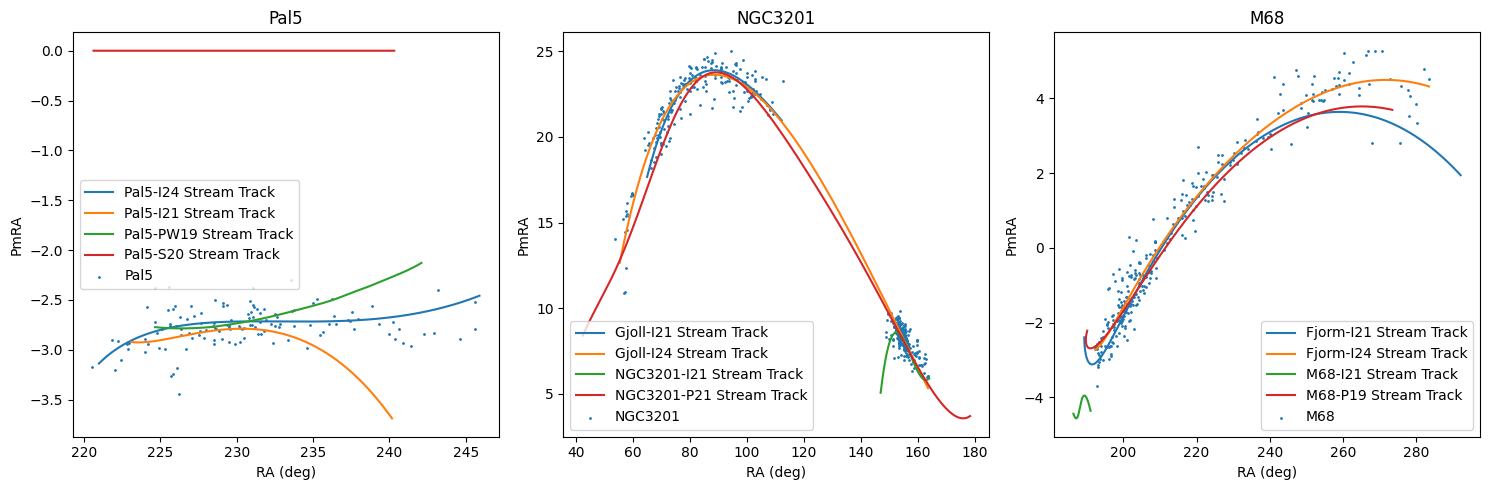

In [7]:
track_name_Pal5 = mws.get_track_names_for_stream('Pal5', On_only=True)
track_name_NGC3201 = mws.get_track_names_for_stream('NGC3201', On_only=True)
track_name_M68 = mws.get_track_names_for_stream('M68', On_only=True)

print("Track name for Pal 5:", track_name_Pal5)
print("Track name for NGC 3201:", track_name_NGC3201)
print("Track name for M68:", track_name_M68)


fig = plt.figure(figsize=(15,5), tight_layout=True)
ax = fig.add_subplot(131)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('PmRA')
ax2 = fig.add_subplot(132)
ax2.set_xlabel('RA (deg)')
ax2.set_ylabel('PmRA')
ax3 = fig.add_subplot(133)
ax3.set_xlabel('RA (deg)')
ax3.set_ylabel('PmRA')

for name in track_name_Pal5:
    track = mws[name].track
    ax.plot(track.ra, track.pm_ra_cosdec, label=f'{name} Stream Track', )

for name in track_name_NGC3201:
    track = mws[name].track
    ax2.plot(track.ra, track.pm_ra_cosdec, label=f'{name} Stream Track', )
# track_ngc3201 = mws[track_name_NGC3201[3]].track
# ax2.plot(track_ngc3201.ra, track_ngc3201.dec, label='NGC 3201 Stream Track', color='orange')

for name in track_name_M68:
    track = mws[name].track
    ax3.plot(track.ra, track.pm_ra_cosdec, label=f'{name} Stream Track', )
# track_m68 = mws[track_name_M68[0]].track
# ax3.plot(track_m68.ra, track_m68.dec, label='M68 Stream Track', color='green')


for i, name in enumerate(name_to_plot):
    if i==0:
        ax.scatter(particles[name]['Ra'], particles[name]['PmRA'], s=1, label=name)
        ax.set_title(name)
    elif i==1:
        ax2.scatter(particles[name]['Ra'], particles[name]['PmRA'], s=1, label=name)
        ax2.set_title(name)
    else:
        ax3.scatter(particles[name]['Ra'], particles[name]['PmRA'], s=1, label=name)
        ax3.set_title(name)
    

ax.legend()
ax2.legend()
ax3.legend()



Track name for Pal 5: ['Pal5-I24', 'Pal5-I21', 'Pal5-PW19', 'Pal5-S20']
Track name for NGC 3201: ['Gjoll-I21', 'Gjoll-I24', 'NGC3201-I21', 'NGC3201-P21']
Track name for M68: ['Fjorm-I21', 'Fjorm-I24', 'M68-I21', 'M68-P19']


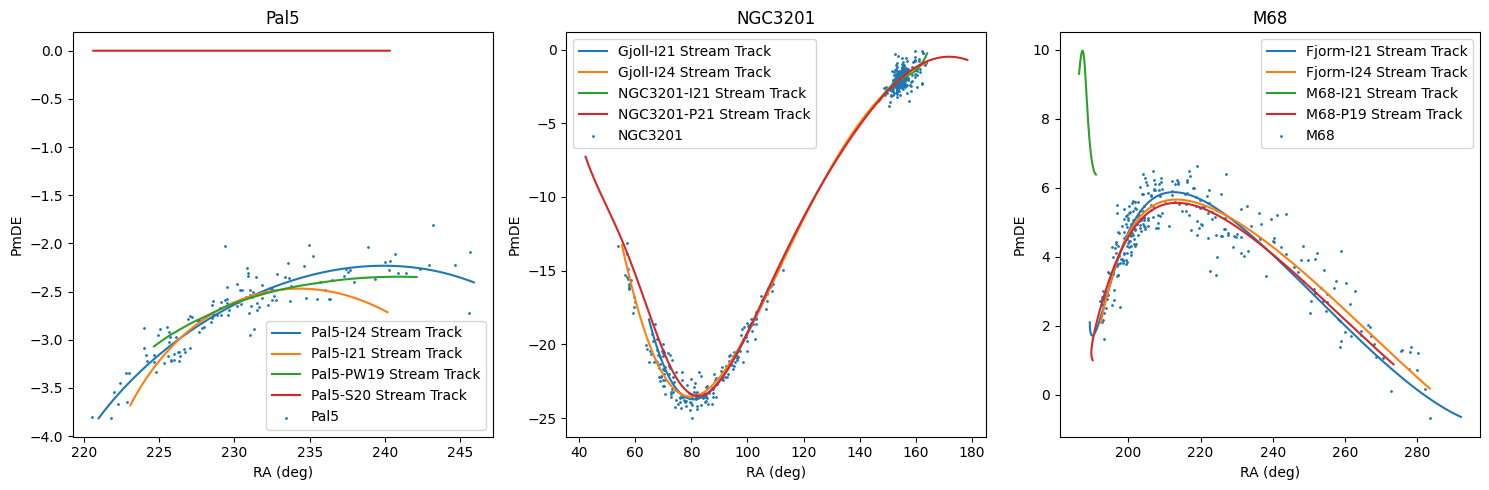

In [8]:
track_name_Pal5 = mws.get_track_names_for_stream('Pal5', On_only=True)
track_name_NGC3201 = mws.get_track_names_for_stream('NGC3201', On_only=True)
track_name_M68 = mws.get_track_names_for_stream('M68', On_only=True)

print("Track name for Pal 5:", track_name_Pal5)
print("Track name for NGC 3201:", track_name_NGC3201)
print("Track name for M68:", track_name_M68)


fig = plt.figure(figsize=(15,5), tight_layout=True)
ax = fig.add_subplot(131)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('PmDE')
ax2 = fig.add_subplot(132)
ax2.set_xlabel('RA (deg)')
ax2.set_ylabel('PmDE')
ax3 = fig.add_subplot(133)
ax3.set_xlabel('RA (deg)')
ax3.set_ylabel('PmDE')

for name in track_name_Pal5:
    track = mws[name].track
    ax.plot(track.ra, track.pm_dec, label=f'{name} Stream Track', )

for name in track_name_NGC3201:
    track = mws[name].track
    ax2.plot(track.ra, track.pm_dec, label=f'{name} Stream Track', )
# track_ngc3201 = mws[track_name_NGC3201[3]].track
# ax2.plot(track_ngc3201.ra, track_ngc3201.dec, label='NGC 3201 Stream Track', color='orange')

for name in track_name_M68:
    track = mws[name].track
    ax3.plot(track.ra, track.pm_dec, label=f'{name} Stream Track', )
# track_m68 = mws[track_name_M68[0]].track
# ax3.plot(track_m68.ra, track_m68.dec, label='M68 Stream Track', color='green')


for i, name in enumerate(name_to_plot):
    if i==0:
        ax.scatter(particles[name]['Ra'], particles[name]['PmDE'], s=1, label=name)
        ax.set_title(name)
    elif i==1:
        ax2.scatter(particles[name]['Ra'], particles[name]['PmDE'], s=1, label=name)
        ax2.set_title(name)
    else:
        ax3.scatter(particles[name]['Ra'], particles[name]['PmDE'], s=1, label=name)
        ax3.set_title(name)
    

ax.legend()
ax2.legend()
ax3.legend()



# Extract Gaia stream data

In [9]:
# Cell to add after particles['Pal5'].keys()

name_to_plot = ['Pal5', 'NGC3201', 'M68']
N_max = 1000
n_features = 6

# Shape: (1, 3, 1000, 6)
sim_data_projected = np.zeros((1, len(name_to_plot), N_max, n_features),)
# Shape: (3, 1000) initially, will add middle dim at the end
attention_mask = np.zeros((len(name_to_plot), N_max))

for i, name in enumerate(name_to_plot):
    p = particles[name]
    n_stars = len(p['Ra'])
    print(f"{name}: {n_stars} stars (padding to {N_max})")
    
    # Stack the 6 features: Ra, Dec, Plx, PmRA, PmDE, VHel
    data = np.column_stack([
        p['Ra'],
        p['Dec'],
        p['Plx'],
        p['PmRA'],
        p['PmDE'],
        p['VHel'],
    ])  # shape: (n_stars, 6)
    
    # Fill into the array (pad with zeros if n_stars < N_max)
    n_fill = min(n_stars, N_max)
    sim_data_projected[0, i, :n_fill, :] = data[:n_fill]
    
    # Set attention mask to 1 where there are real stars
    attention_mask[i, :n_fill] = 1.0

# Add the middle dimension: (3, 1000) -> (3, 1, 1000)
attention_mask = attention_mask[:, np.newaxis, :]

# j array mapping: 0 -> Pal5, 1 -> NGC3201, 2 -> M68
j = np.array([0, 1, 2]).reshape(1, len(name_to_plot), 1)

print(f"sim_data_projected shape: {sim_data_projected.shape}")
print(f"attention_mask shape: {attention_mask.shape}")
print(f"j: {j}")

np.savez(
    "../data/gaia_observed_streams.npz",
    j=j,
    sim_data_projected=sim_data_projected,
    attention_mask=attention_mask,
)
print("Saved to ../data/gaia_observed_streams.npz")

Pal5: 129 stars (padding to 1000)
NGC3201: 607 stars (padding to 1000)
M68: 297 stars (padding to 1000)
sim_data_projected shape: (1, 3, 1000, 6)
attention_mask shape: (3, 1, 1000)
j: [[[0]
  [1]
  [2]]]
Saved to ../data/gaia_observed_streams.npz


Loaded sim_data shape: (1, 3, 1000, 6)
Loaded j shape: (1, 3, 1)


Text(0, 0.5, 'Dec [deg]')

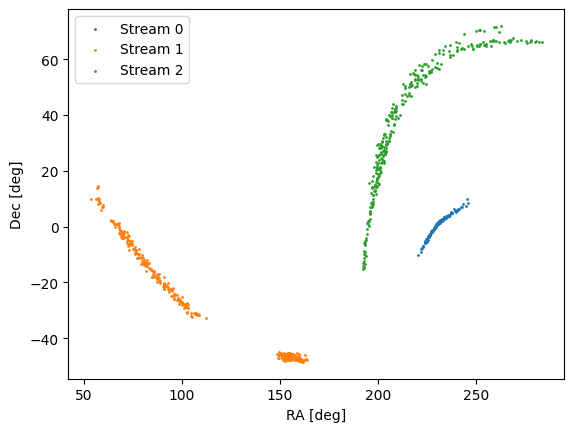

In [10]:
data = np.load("../data/gaia_observed_streams.npz")
sim_data = data['sim_data_projected']
j = data['j']
print(f"Loaded sim_data shape: {sim_data.shape}")
print(f"Loaded j shape: {j.shape}")
attention_mask = data['attention_mask'].astype(bool)
for i in range(sim_data.shape[1]):
    plt.scatter(sim_data[0, i, attention_mask[i, 0, :], 0], sim_data[0, i, attention_mask[i, 0, :], 1], s=1, label=f"Stream {j[0, i, 0]}")
plt.legend()
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')